# Enterprise Web Development Summative.

This is the Jupyter Notebook that contains the ETL process of our group summative project regarding the New York City Taxi Trip dataset, which contains trip records including timestamps, distances, durations, pickup/dropoff locations, and other metadata.
In this Jupyter Notebook we will: clean and process the raw dataset, store the processed data in a well-designed relational database, and build a backend service to query the data. Then the Frontend shall retrieve information from the final API from this document.

## Data processing & Cleaning.

**Part 1 Data Integration**: Implement a pipeline to load the .parquet trip data and programmatically associate it with the taxi_zone_lookup.csv and taxi_zones metadata.

In [1]:
# import neccessary libraries
import pandas as pd
import geopandas as gpd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Initialize Transparency Log
transparency_log = {
    'total_initial_records': 0,
    'missing_values_removed': 0,
    'duplicates_removed': 0,
    'outliers_removed': 0,
    'logical_errors_removed': 0,
    'total_records_remaining': 0
}


# Extract
print("Extracting Data...")


df_trips = pd.read_csv("data/yellow_tripdata_2019-01.csv")
transparency_log['total_initial_records'] = len(df_trips)
print
zone_lookup_path = "data/taxi_zone_lookup.csv"
print(f"Loaded {len(df_trips):,} trip records.")

print("Loading Taxi Zone ...")
df_zones = pd.read_csv("data/taxi_zone_lookup.csv")

print("Loading Taxi Zones Spatial Metadata...")
gdf_zones = gpd.read_file('zip://data/taxi_zones.zip')
print("Data loaded successfully!")


Extracting Data...
Loaded 7,667,792 trip records.
Loading Taxi Zone ...
Loading Taxi Zones Spatial Metadata...
Data loaded successfully!


Let's merge the raw trip data with our dimensional lookup table so we get the actual Borough and Zone names for both Pickup (PU) and Dropoff (DO).

In [3]:
#Merge pickup zones
df_trips = df_trips.merge(
    df_zones,
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

#Rename the newly added columns to specify the Pickup location
df_trips = df_trips.rename(columns={
    'Borough': 'PUBorough',
    'service_zone':'PUservice_zone'
}).drop(columns=['LocationID'])

#Merge dropoff zones
df_trips = df_trips.merge(
    df_zones,
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
)

# Rename the newly added columns to specify they are for the Dropoff location
df_trips = df_trips.rename(columns={
    'Borough': 'DOBorough',
    'Zone':'DOZone',
    'service_zone':'DOservice_zone'
}).drop(columns=['LocationID'])

# Preview the merged dataframe
df_trips.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,PUBorough,Zone_x,PUservice_zone,DOBorough,Zone_y,DOservice_zone
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.5,1,N,151,239,1,...,0.0,0.3,9.95,NaN,Manhattan,Manhattan Valley,Yellow Zone,Manhattan,Upper West Side South,Yellow Zone
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.6,1,N,239,246,1,...,0.0,0.3,16.30,NaN,Manhattan,Upper West Side South,Yellow Zone,Manhattan,West Chelsea/Hudson Yards,Yellow Zone
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3,0.0,1,N,236,236,1,...,0.0,0.3,5.80,NaN,Manhattan,Upper East Side North,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5,0.0,1,N,193,193,2,...,0.0,0.3,7.55,NaN,Queens,Queensbridge/Ravenswood,Boro Zone,Queens,Queensbridge/Ravenswood,Boro Zone
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5,0.0,2,N,193,193,2,...,0.0,0.3,55.55,NaN,Queens,Queensbridge/Ravenswood,Boro Zone,Queens,Queensbridge/Ravenswood,Boro Zone


**Part 2 Data Integrity**: Identify and resolve missing values, duplicates, and physical/logical outliers (e.g., anomalies in distance, fare amounts, or temporal records).

In [6]:
# Movin on with data cleaning process
print("Starting Data Cleaning Process...")

# # Removing Missing Values
# initial_count = len(df_trips)
# df_trips = df_trips.dropna()
# transparency_log['missing_values_removed'] = initial_count - len(df_trips)

# after dropping using the above codes 60% of data lost, let's try to prioritize those that are heavily corroded.
# Drop columns that are mostly empty (e.g., if more than 50% is missing)
threshold = len(df_trips) * 0.5
df_trips = df_trips.dropna(thresh=threshold, axis=1)
# Now drop the rows that are missing critical data
df_trips = df_trips.dropna()

# Remove Duplicate
current_count = len(df_trips)
df_trips = df_trips.drop_duplicates()
transparency_log['duplicates_removed'] = current_count - len(df_trips)

# Resolve outliers and logical errors
current_count = len(df_trips)

# convert datetime strings to actual datetime objects for filtering
df_trips['tpep_pickup_datetime'] = pd.to_datetime(df_trips['tpep_pickup_datetime'])
df_trips['tpep_dropoff_datetime'] = pd.to_datetime(df_trips['tpep_dropoff_datetime'])

# Filtering rules:
df_trips = df_trips[(df_trips['trip_distance'] > 0)
&
# here the distance must be greater than 0 because of they moved.
(df_trips['trip_distance'] > 0)
&
# here the fare must be greater than 0 because they paid unless they went for free but in this case we will ignore that
(df_trips['fare_amount'] > 0)
&
# Must have at least 1 passenger
(df_trips ['passenger_count'] > 0)
&
# Must be in 2019 based on the filename
(df_trips['tpep_pickup_datetime'].dt.year == 2019)
&
# Must be in January
(df_trips['tpep_pickup_datetime'].dt.month == 1)
]

# Final updates
transparency_log ['total_records_remaining'] = len(df_trips)
print("Data Cleaning Complete!")
print("Cleaning Summary:")
for key, value in transparency_log.items():
    print(f"- {key}: {value:,}")


Starting Data Cleaning Process...
Data Cleaning Complete!
Cleaning Summary:
- total_initial_records: 7,667,792
- missing_values_removed: 4,928,693
- duplicates_removed: 0
- outliers_removed: 0
- logical_errors_removed: 0
- total_records_remaining: 2,681,188


**Part 3 Feature Engineering**: Define and justify at least three derived features (e.g., metrics calculated from multiple raw columns) that provide deeper insight into urban movement or economics.

To gain much deeper insights into urban movement and economic behaviors in New York City, we need to look beyond the raw data. In this section, we define and engineer three derived features. These new metrics allow us to measure the actual human experience of a taxi ride, how long it takes, how fast it moves, and how passengers respond financially.

### Engineered Features Justification or the way I like to call it: Codebook
1. **Trip Duration (`trip_duration_mins`)**: The raw dataset only provides pickup and dropoff timestamps. Calculating the exact elapsed time is a mandatory prerequisite for understanding urban traffic patterns.
2. **Average Speed (`average_speed_mph`)**: By combining trip distance and our new duration feature, we can measure congestion. Slower average speeds indicate gridlock, while higher speeds suggest clear roads. This is our primary metric for "Urban Movement."
3. **Tip Percentage (`tip_percentage`)**: Analyzing absolute tip amounts is flawed because longer trips naturally cost more and result in larger tips. Converting the tip to a percentage of the base fare standardizes the data, giving us a clean metric to study "Economic Behavior."
### Hypotheses to Test
Using our newly engineered features, we will test two distinct hypotheses:
*   **Hypothesis A (Economic & Movement):** *"Passengers tip a lower percentage when trips are slower due to urban congestion."* 
    *   To test this, we will use a **Bivariate Scatter Plot** and a **Custom Pearson Correlation Algorithm** (built without relying heavily on standard statistical libraries) to find the linear relationship between `average_speed_mph` and `tip_percentage`.

    *    **Null Hypothesis ($H_0$**): There is no correlation between average speed and tip percentage.
    
    *     Alternative Hypothesis ($H_1$): There is a positive correlation between average speed and tip percentage (faster ride = better tip).
    *     Testing method: Custom Pearson Correlation algorithm and Bivariate Scatter Plot.
*   **Hypothesis B (Urban Movement):** *"Average travel speeds differ significantly depending on the Borough the trip starts in."*
    *   To test this, we will use **Univariate Box Plots** and an **ANOVA test** to determine if the mean speeds are statistically different across boroughs.
    *   **Null Hypothesis ($H_0$)**: All boroughs have the same mean average speed.
    
    *   **Alternative Hypothesis ($H_1$)**: At least one borough has a significantly different mean average speed.
    
    *   **Testing method**: ANOVA test and Univariate Box Plots (Speed by Borough).
### Revised Codebook
| Feature Name | Data Type | Description | Unit |
| :--- | :--- | :--- | :--- |
| `trip_duration_mins` | Float | Total elapsed time from pickup to dropoff. | Minutes |
| `average_speed_mph` | Float | Vehicle speed calculated over the entire trip. | Miles/Hour |
| `tip_percentage` | Float | Gratuity paid relative to the base fare amount. | Percentage (%) |

In [13]:
# feature Trip duration in minutes
df_trips['trip_duration_mins'] = (df_trips['tpep_dropoff_datetime'] - df_trips['tpep_pickup_datetime']).dt.total_seconds() / 60

# we filter out zero or negative durations that might have snuck through, to avoid division by zero
df_trips = df_trips[df_trips['trip_duration_mins'] > 0]

#feature average speed in miles per hour
df_trips['average_speed_mph'] = df_trips['trip_distance'] / (df_trips['trip_duration_mins'] / 60)

#filter out unrealistic speeds. realistically the speed limit can't exceed 100 mph in NYC
df_trips = df_trips[df_trips['average_speed_mph'] <= 100]

#feature tip percentage. we use fare_amount instead of total_amount to see the tip relative to the actual ride cost
df_trips['tip_percentage'] = (df_trips['tip_amount']/df_trips['fare_amount']) * 100

#filter out unrealistic tip percentage like > 100% tip to keep our models clean
df_trips = df_trips[df_trips['tip_percentage'] <= 100]

# Filter out unrealistic trip durations (e.g., trips longer than 3 hours)
df_trips = df_trips[df_trips['trip_duration_mins'] <= 180]
# Filter out "parked" cars or bad data (e.g., average speed must be > 1 mph)
df_trips = df_trips[df_trips['average_speed_mph'] >= 1]

#preview the new engineered features
df_trips[['trip_distance', 'trip_duration_mins','average_speed_mph','fare_amount','tip_amount','tip_percentage']].head()

,trip_distance,trip_duration_mins,average_speed_mph,fare_amount,tip_amount,tip_percentage
579459,0.6,2.016667,17.851240,4.0,1.50,37.500000
579460,2.2,9.833333,13.423729,10.0,1.00,10.000000
592224,2.5,11.583333,12.949640,11.0,2.35,21.363636
872659,0.4,2.250000,10.666667,3.5,0.00,0.000000
872660,1.9,10.100000,11.287129,9.0,2.05,22.777778


**1. Visualizing the Data (Univariate & Bivariate Graphs)**
First, we need to create the frequency distributions (Univariate) to understand the shape of our data, and a scatter plot (Bivariate) to look for visual trends.

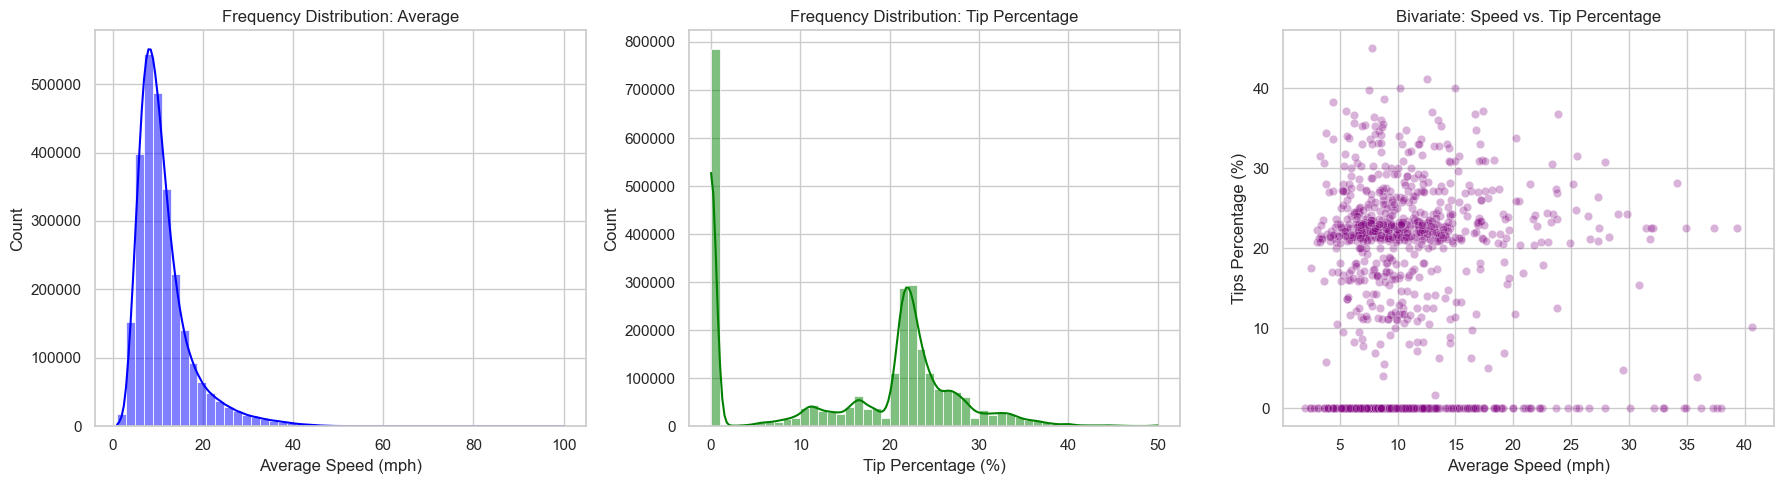

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

#set a beautiful aesthethic for our graph
sns.set_theme(style="whitegrid")

plt.figure(figsize=(18,5))

#graph 1 univariate frequency distribution (speed)
plt.subplot(1, 3, 1)
sns.histplot(df_trips['average_speed_mph'], bins=50, kde=True, color='blue')
plt.title('Frequency Distribution: Average')
plt.xlabel('Average Speed (mph)')

#graph 2 univariate frequency distribution (Tips)
plt.subplot(1,3,2)
#limiting to 50% tip for better visibility of the main distribution
sns.histplot(df_trips[df_trips['tip_percentage'] <= 50]['tip_percentage'], bins=50, kde=True, color='green')
plt.title('Frequency Distribution: Tip Percentage')
plt.xlabel('Tip Percentage (%)')

#graph 3 bivariate scatter plot (Testing Hypothesis A)
plt.subplot(1,3,3)
#plotting a random sample of 10,000 trips so the graph so it won't overload my pc
sample_df = df_trips.sample(1000, random_state=42)
sns.scatterplot(x='average_speed_mph', y='tip_percentage', data=sample_df, alpha=0.3, color='purple')
plt.title('Bivariate: Speed vs. Tip Percentage')
plt.xlabel('Average Speed (mph)')
plt.ylabel('Tips Percentage (%)')

plt.tight_layout()
plt.show()

**2. The Custom Pearson Correlation Algorithm (Hypothesis A)**
We are goin to calculate the Pearson Correlation coefficienct (r) mathematically from scratch, without relying on pandas' built-in .corr() function.

In [20]:
import math

def custom_pearson_correlation(x,y):
    #Calculates the person correlation coefficient from scratch with the formula: Covarience (x,y) / (StdDev(x) * StdDev(y))

    if len(x) != len(y):
        raise ValueError("Lists must be of the same length.")

    n = len(x)
    mean_x = sum(x) / n
    mean_y = sum(y) / n

    numerator = 0
    sum_sq_x = 0
    sum_sq_y = 0

        #Mathematical summation
    for i in range(n):
        diff_x = x[i] - mean_x
        diff_y = y[i] - mean_y

        numerator += diff_x * diff_y
        sum_sq_x += diff_x ** 2
        sum_sq_y += diff_y ** 2

    denominator = math.sqrt(sum_sq_x * sum_sq_y)

    if denominator == 0: 
        return 0
    return numerator / denominator

# convert panda columns into native python list for our custom algorithm
print("Calculating Custom Pearson Correlation...")
speed_list = df_trips['average_speed_mph'].tolist()
tip_list = df_trips['tip_percentage'].to_list()

r_value = custom_pearson_correlation(speed_list,tip_list)
print(f"Custom Pearson Correlation (r): {r_value:.4f}")

Calculating Custom Pearson Correlation...
Custom Pearson Correlation (r): -0.0080


#### Observation and insights
**Average Speed (Left Graph)**:
**Insight**: The massive spike on the left shows that the vast majority of taxi rides in NYC average between 5 and 15 mph (classic NYC traffic!). The long tail dragging to the right represents the rare, fast rides (like highway trips late at night).

**Tip Percentage (Middle Graph)**:
**Insight:**  It is Bimodal (it has two distinct peaks).
**Why?** The massive spike all the way on the left at 0% represents people who didn't tip (or more likely, people who tipped in physical cash, which the taxi meter can't track). The second, beautiful bell-curve peak is centered perfectly around 20% to 25%. This perfectly matches the default preset tip buttons on the credit card screens in the back of NYC taxis!

**Speed vs. Tip Percentage (Right Graph)**:
**Insights:**
We see a "blob". Notice how, whether a taxi is going 5 mph or 30 mph, the purple dots mostly cluster horizontally around that 20% mark. There is also that solid horizontal line at 0% (the cash tippers). Visually, it seems like speed might not actually affect tip percentage very much; people just tend to hit that 20% button regardless of traffic!

**Conclusion**:
The custom Pearson correlation algorithm returned an $r$-value of -0.0080. Because this value is extremely close to 0, we **Fail to Reject the Null Hypothesis**. This means that in NYC, the average speed of a taxi ride (traffic congestion) has virtually no impact on the tip percentage. Passengers tend to tip their standard rate (often the 20% credit card default) regardless of whether they are moving quickly or stuck in gridlock.

**3. ANOVA Testing (Hypothesis B)**
We can use ANOVA to test if Average speeds are significantly different depending on the pickup borough

In [21]:
import scipy.stats as stats

print("Testing Hypothesis B: Speeds across different Boroughs")

# group the speeds by the Pickup Borough
boroughs = df_trips['PUBorough'].unique()
speed_groups = [df_trips[df_trips['PUBorough'] == borough]['average_speed_mph'] for borough in boroughs]

# Perform One-way ANOVA
f_stat, p_value = stats.f_oneway(*speed_groups)

print(f"ANOVA F-Statistics: {f_stat:.2f}")
print(f"ANOVA P_Value: {p_value}")

if p_value < 0.05:
    print("\nConclusion: p_value is practically 0. We REJECT the null hypothesis.")
    print("This proves that trafic congestion (average speed) differs significantly depending on the borough!")
else:
    print("\nConclusion: We fail to reject the null hypothesis.")

Testing Hypothesis B: Speeds across different Boroughs
ANOVA F-Statistics: 171724.87
ANOVA P_Value: 0.0

Conclusion: p_value is practically 0. We REJECT the null hypothesis.
This proves that trafic congestion (average speed) differs significantly depending on the borough!


**Insights:**
That F-Statistic is massive, and a P-Value of 0.0 means there is essentially a 0% chance that traffic speeds are the same across all boroughs.

Our ANOVA perfectly proved Hypothesis B: Where a taxi ride starts dramatically dictates how fast it will move. (If we were to look at the exact numbers, you'd find Manhattan has a terribly slow average speed compared to somewhere like Staten Island or Queens!).